In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import pandas as pd
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
import numpy as np
import unicodedata
import glob, os
from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [2]:
def myVenn(df, c1, c2, c3, savepath=None):
    """
    Create a Venn diagram showing overlap of correct predictions between three models.
    
    Parameters:
    - df: DataFrame with prediction columns
    - c1, c2, c3: Column names for the three models to compare
    - savepath: Optional path to save the figure
    """
    # Pastel color palette
    venn_colors = ["#8DA0CB", "#FDBF6F", "#66C2A5"]
    
    # Create unique identifiers for correct predictions
    # For oncogenic driver, we need to include both SAMPLE_ID and gene
    df[f"{c1}_set"] = df[c1] + df['SAMPLE_ID'] + df.get('gene', '')
    df[f"{c2}_set"] = df[c2] + df['SAMPLE_ID'] + df.get('gene', '')
    df[f"{c3}_set"] = df[c3] + df['SAMPLE_ID'] + df.get('gene', '')

    plt.figure(figsize=(9, 8))
    venn = venn3(
        subsets=([set(df[f"{c1}_set"]), set(df[f"{c2}_set"]), set(df[f"{c3}_set"])]),
        set_labels=(c1.replace("_", " "), c2.replace("_", " "), c3.replace("_", " ")),
        set_colors=venn_colors,
        alpha=0.6
    )

    venn3_circles(
        subsets=([set(df[f"{c1}_set"]), set(df[f"{c2}_set"]), set(df[f"{c3}_set"])]),
        linestyle="solid", linewidth=1.2, color="gray"
    )

    # Add labels with counts and percentages
    total = len(df)
    region_codes = ['001', '010', '100', '011', '110', '101', '111']
    
    for code in region_codes:
        lbl = venn.get_label_by_id(code)
        if lbl and int(lbl.get_text()) > 0:
            pct = f"{int(lbl.get_text())/total:.1%}"
            lbl.set_text(f"{int(lbl.get_text())}\n{pct}")
            lbl.set_fontsize(16)
            lbl.set_color("gray")
            lbl.set_weight("bold")
    
    # Style set labels
    for lbl in venn.set_labels:
        if lbl:
            lbl.set_fontsize(20)
            lbl.set_weight("bold")
            lbl.set_color("black")
    
    if savepath:
        plt.savefig(savepath, dpi=500, bbox_inches='tight')
    plt.show()

def normalize(name):
    """Normalize unicode characters in names."""
    name = unicodedata.normalize('NFKD', name)
    name = name.replace('‑', '-')  # non-breaking hyphen
    name = name.replace('‐', '-')  # hyphen
    name = name.replace('–', '-')  # en dash
    name = name.replace('—', '-')  # em dash
    name = name.replace(',', '')  # remove commas
    return name

## Load oncogenic driver identification results

In [3]:
"""Load and prepare the oncogenic driver data for Venn diagram analysis."""

# Configuration
BASE_RESULTS_DIR = "/data1/morrisq/yuj13/llm_genomics/mutation_output/impact_oncogenic_sample"
SAMPLE_TSVS = [
    '/data1/morrisq/yuj13/llm_genomics/msk_solid_heme/data_clinical_sample.txt'
]
MODEL_NAMES = ["gpt-5", "gpt-4o", "o3-mini", "claude-sonnet-37", "deepseek", "qwen3", "medgemma", "AlphaMissense"]

# Helper functions
def build_sampleid_to_cancer(sample_tsvs):
    """Build mapping from SAMPLE_ID to CANCER_TYPE from clinical data."""
    samp2ct = {}
    for tsv_path in sample_tsvs:
        df_temp = pd.read_csv(tsv_path, sep='\t', comment='#')
        for _, row in df_temp.iterrows():
            samp2ct[row['SAMPLE_ID']] = row.get('CANCER_TYPE', 'UNKNOWN')
    return samp2ct

def load_all_model_predictions(model_dirs, model_names, samp2ct, ground_truth_label='OncoKB_label', gene_col='gene'):
    """Load predictions from all models and merge into single dataframe."""
    merged = None
    
    for model_dir, model_name in zip(model_dirs, model_names):
        csv_files = glob.glob(os.path.join(model_dir, "*.csv"))
        if not csv_files:
            print(f"Warning: No CSV files found for {model_name}")
            continue
        
        df = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
        
        # Add CANCER_TYPE from sample mapping
        df['CANCER_TYPE'] = df['SAMPLE_ID'].map(samp2ct)
        
        if merged is None:
            # First model: initialize merged dataframe
            merged = df[['SAMPLE_ID', 'CANCER_TYPE']].copy()
            # Add gene column if present
            if gene_col in df.columns:
                merged['gene'] = df[gene_col]
            elif 'Gene' in df.columns:
                merged['gene'] = df['Gene']
            # Rename the label column to 'ground_truth'
            if ground_truth_label in df.columns:
                merged['ground_truth'] = df[ground_truth_label]
            elif 'label' in df.columns:
                merged['ground_truth'] = df['label']
        
        # Add model-specific prediction and probability columns
        if 'prediction' in df.columns:
            merged[f'{model_name}_pred'] = df['prediction']
        if 'prob' in df.columns:
            merged[f'{model_name}_prob'] = df['prob']
    
    return merged

# Load data
print("Building sample-to-cancer mapping...")
samp2ct = build_sampleid_to_cancer(SAMPLE_TSVS)

print("Loading model predictions...")
MODEL_DIRS = [os.path.join(BASE_RESULTS_DIR, model) for model in MODEL_NAMES]
merged_predictions = load_all_model_predictions(MODEL_DIRS, MODEL_NAMES, samp2ct, 
                                                ground_truth_label='OncoKB_label', 
                                                gene_col='gene')

# Drop rows with UNKNOWN or ERROR
print(f"Total samples before filtering: {len(merged_predictions)}")
for col in merged_predictions.columns:
    if '_pred' in col:
        merged_predictions = merged_predictions[
            (~merged_predictions[col].astype(str).str.contains('UNKNOWN', case=False, na=False)) &
            (~merged_predictions[col].astype(str).str.contains('ERROR', case=False, na=False))
        ]

# Filter out VUS predictions for AlphaMissense
if 'AlphaMissense_pred' in merged_predictions.columns:
    print(f"Samples with AlphaMissense VUS predictions: {(merged_predictions['AlphaMissense_pred'] == 'VUS').sum()}")
    merged_predictions = merged_predictions[merged_predictions['AlphaMissense_pred'] != 'VUS']

print(f"Total samples after filtering: {len(merged_predictions)}")

# Create columns for correctly predicted samples (matching ground truth)
for model_name in MODEL_NAMES:
    pred_col = f'{model_name}_pred'
    if pred_col in merged_predictions.columns:
        # Create a column that shows correct predictions
        correct_mask = merged_predictions[pred_col] == merged_predictions['ground_truth']
        merged_predictions[f'{model_name}_correct'] = merged_predictions[pred_col].where(correct_mask, '')

print(f"\nDataframe shape: {merged_predictions.shape}")
if 'ground_truth' in merged_predictions.columns:
    print(f"\nGround truth classes: {merged_predictions['ground_truth'].unique()}")

Building sample-to-cancer mapping...


/tmp/ipykernel_3954951/2513342784.py:15: DtypeWarning: Columns (3,15,17,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(tsv_path, sep='\t', comment='#')


Loading model predictions...
Total samples before filtering: 14405
Samples with AlphaMissense VUS predictions: 0
Total samples after filtering: 14404

Dataframe shape: (14404, 28)

Ground truth classes: ['Benign' 'Oncogenic']


## Generate Venn diagrams comparing model predictions

Samples for Venn diagram: 14404

Accuracy by model:
gpt-5: 76.00%
gpt-4o: 42.41%
o3-mini: 66.64%
claude-sonnet-37: 57.84%
deepseek: 67.41%
qwen3: 67.63%
medgemma: 63.00%
AlphaMissense: 86.35%


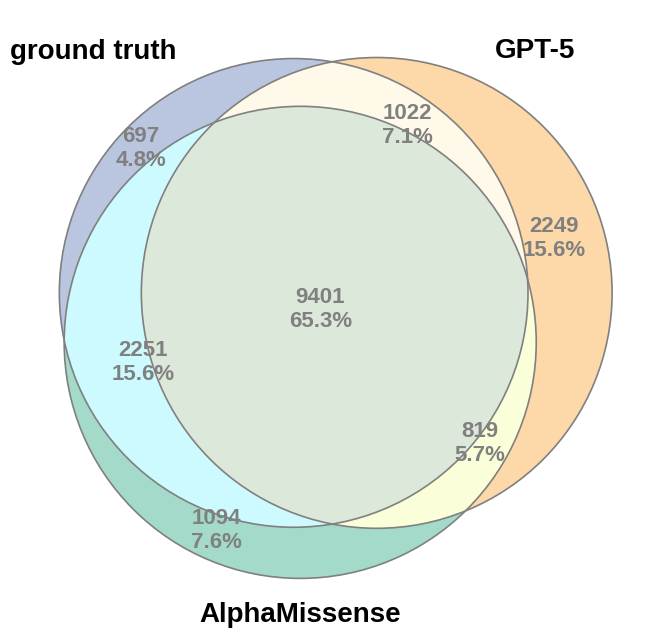

In [5]:
"""Generate Venn diagrams comparing correct predictions across models."""

# Example: Compare ground truth with two models
# You can modify these to compare different model combinations

# Filter to only include rows where all three columns have data
venn_df = merged_predictions.dropna(subset=['ground_truth', 'gpt-5_correct', 'AlphaMissense_correct'])

print(f"Samples for Venn diagram: {len(venn_df)}")
print(f"\nAccuracy by model:")
for model_name in MODEL_NAMES:
    correct_col = f'{model_name}_correct'
    pred_col = f'{model_name}_pred'
    if correct_col in venn_df.columns:
        accuracy = (venn_df[correct_col] != '').sum() / len(venn_df)
        print(f"{model_name}: {accuracy:.2%}")

# Generate Venn diagram: ground truth vs two models
venn_df.rename(columns={'gpt-5_correct': 'GPT-5', 'AlphaMissense_correct': 'AlphaMissense'}, inplace=True)

myVenn(venn_df, 'ground_truth', 'GPT-5', 'AlphaMissense', 
       savepath="ground_truth_gpt5_alphamissense_venn.png")

# You can add more Venn diagrams by uncommenting and modifying:
# myVenn(venn_df, 'ground_truth', 'gpt-4o_correct', 'o3-mini_correct', 
#        savepath="ground_truth_gpt4o_o3mini_venn.png")